In [1]:
import numpy as np
import mujoco as mj
import os


Video shape: (240, 512, 512, 3), Frame shape: (512, 512, 3), Tracks shape: (240, 34, 3)
[[181.  37.]
 [189.  46.]
 [197.  54.]
 [206.  61.]
 [215.  67.]
 [224.  73.]
 [234.  77.]
 [244.  79.]
 [254.  80.]
 [265.  80.]
 [275.  78.]
 [285.  74.]
 [294.  69.]
 [303.  63.]
 [312.  56.]
 [320.  48.]
 [327.  40.]]


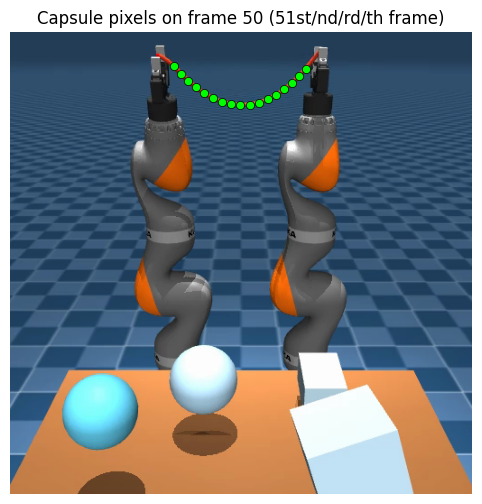

In [6]:
import numpy as np
import mediapy as media
import matplotlib.pyplot as plt
tracks = np.load("data/teleop_rope_tracks_txy.npy")   # shape: (T, N_capsules, 3) -> [frame, x, y]
video = media.read_video("data/teleop_front_camera.mp4")  # adjust path if needed

frame_idx = 50
img = video[frame_idx]
print(f"Video shape: {video.shape}, Frame shape: {img.shape}, Tracks shape: {tracks.shape}")
xy = tracks[frame_idx, :, 1:3]   # x, y for all capsules
# keep only valid coordinates
h, w = img.shape[:2]
valid = (
    (xy[:, 0] >= 0) & (xy[:, 0] < w) &
    (xy[:, 1] >= 0) & (xy[:, 1] < h)
)
xy = xy[valid]
print(xy)
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.scatter(xy[:, 0], xy[:, 1], s=35, c="lime", edgecolors="black", linewidths=0.5)
plt.title(f"Capsule pixels on frame {frame_idx} ({frame_idx + 1}st/nd/rd/th frame)")
plt.axis("off")
plt.show()